In [1]:
import pandas as pd
df = pd.read_csv('Weather_data.csv')

In [2]:
df

,datetime_utc,_conds,_dewptm,_fog,_hail,_heatindexm,_hum,_precipm,_pressurem,_rain,_snow,_tempm,_thunder,_tornado,_vism,_wdird,_wdire,_wgustm,_windchillm,_wspdm
0,19961101-11:00,Smoke,9.0,0,0,NaN,27.0,NaN,1010.0,0,0,30.0,0,0,5.0,280.0,West,NaN,NaN,7.4
1,19961101-12:00,Smoke,10.0,0,0,NaN,32.0,NaN,-9999.0,0,0,28.0,0,0,NaN,0.0,North,NaN,NaN,NaN
2,19961101-13:00,Smoke,11.0,0,0,NaN,44.0,NaN,-9999.0,0,0,24.0,0,0,NaN,0.0,North,NaN,NaN,NaN
3,19961101-14:00,Smoke,10.0,0,0,NaN,41.0,NaN,1010.0,0,0,24.0,0,0,2.0,0.0,North,NaN,NaN,NaN
4,19961101-16:00,Smoke,11.0,0,0,NaN,47.0,NaN,1011.0,0,0,23.0,0,0,1.2,0.0,North,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98908,20161130-12:30,Mist,17.0,0,0,NaN,78.0,NaN,1015.0,0,0,21.0,0,0,1.5,0.0,North,NaN,NaN,0.0
98909,20161130-13:00,Mist,16.0,0,0,NaN,83.0,NaN,1015.0,0,0,19.0,0,0,1.2,0.0,North,NaN,NaN,0.0
98910,20161130-15:00,Patches of Fog,16.0,1,0,NaN,90.0,NaN,1016.0,0,0,17.0,0,0,1.0,NaN,NaN,NaN,NaN,0.0
98911,20161130-18:00,Patches of Fog,14.0,1,0,NaN,96.0,NaN,1017.0,0,0,15.0,0,0,1.0,NaN,NaN,NaN,NaN,0.0


In [3]:
df1 = df.copy()

In [4]:
import numpy as np

In [5]:
df1 = df1[' _tempm']

In [6]:
df1.dropna(inplace=True)

In [7]:
df1 = pd.DataFrame(df1)

In [8]:
df1['datetime_utc'] = df['datetime_utc']
df1['datetime_utc'] = pd.to_datetime(df1['datetime_utc'])
df1['daily_temp'] = df1['datetime_utc'].dt.to_period('D')
df1.groupby('daily_temp').mean()

,_tempm
daily_temp,
1996-11-01,22.333333
1996-11-02,22.916667
1996-11-03,21.791667
1996-11-04,22.722222
1996-11-05,27.800000
...,...
2016-11-26,24.294118
2016-11-27,23.636364
2016-11-28,22.454545


In [9]:
df1 = df1.groupby('daily_temp').mean()

In [10]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

In [11]:
import matplotlib.pyplot as plt

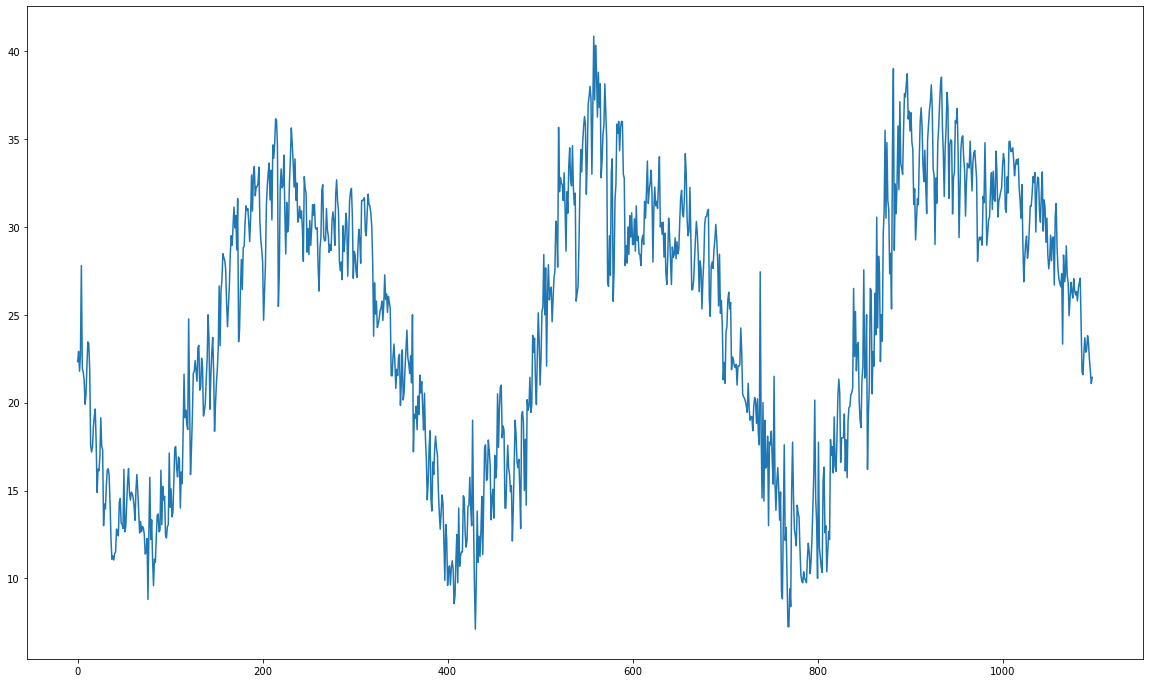

In [12]:
plt.figure(figsize=(20,12))
plt.plot(df1[:366*3].values)

In [13]:
y = df1.values.reshape(len(df1),)

In [14]:
import numpy as np

def prepare_data(seq,num):
    
    x=[]
    y=[]
    
    for i in range(0,(len(seq)-num)):
        input_ = seq[i:i+num]
        output  = seq[i+num]
        
        x.append(input_)
        y.append(output)
    
    return np.array(x), np.array(y)

In [15]:
num=365

x,yt= prepare_data(y,num)

In [16]:
x = pd.DataFrame(x)
yt = pd.DataFrame(yt)

In [17]:
x

,0,1,2,3,4,5,6,7,8,9,...,355,356,357,358,359,360,361,362,363,364
0,22.333333,22.916667,21.791667,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,...,23.100000,24.125000,22.555556,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333
1,22.916667,21.791667,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,...,24.125000,22.555556,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111
2,21.791667,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,...,22.555556,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000
3,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,23.363636,...,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000,18.461538
4,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,23.363636,21.888889,...,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000,18.461538,20.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6821,18.500000,18.750000,18.125000,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,...,21.769231,21.730769,21.730769,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000
6822,18.750000,18.125000,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,...,21.730769,21.730769,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118
6823,18.125000,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,18.428571,...,21.730769,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118,23.636364
6824,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,18.428571,18.375000,...,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118,23.636364,22.454545


In [18]:
yt

,0
0,19.111111
1,19.800000
2,18.461538
3,20.375000
4,19.333333
...,...
6821,24.294118
6822,23.636364
6823,22.454545
6824,21.611111


In [19]:
X = sm.add_constant(x)
lr_ols = OLS(yt, X)
results = lr_ols.fit()

# print the summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      0   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     373.1
Date:                Wed, 02 Mar 2022   Prob (F-statistic):               0.00
Time:                        17:33:36   Log-Likelihood:                -12841.
No. Observations:                6826   AIC:                         2.641e+04
Df Residuals:                    6460   BIC:                         2.891e+04
Df Model:                         365                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6320      0.649      4.057      0.0

In [20]:
dft = df1[' _tempm']
dft

daily_temp
1996-11-01    22.333333
1996-11-02    22.916667
1996-11-03    21.791667
1996-11-04    22.722222
1996-11-05    27.800000
                ...    
2016-11-26    24.294118
2016-11-27    23.636364
2016-11-28    22.454545
2016-11-29    21.611111
2016-11-30    19.869565
Freq: D, Name:  _tempm, Length: 7191, dtype: float64

In [21]:
import numpy as np

def prepare_data(seq,num):
    
    x=[]

    for i in range(0,(len(seq)-num)):
        
        input_ = seq[i+1:i+num+1]
        
        
        x.append(input_)
       
    
    return np.array(x)

In [22]:
dft = pd.DataFrame(prepare_data(dft,365))

In [23]:
dft

,0,1,2,3,4,5,6,7,8,9,...,355,356,357,358,359,360,361,362,363,364
0,22.916667,21.791667,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,...,24.125000,22.555556,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111
1,21.791667,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,...,22.555556,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000
2,22.722222,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,23.363636,...,22.222222,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000,18.461538
3,27.800000,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,23.363636,21.888889,...,21.666667,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000,18.461538,20.375000
4,21.937500,21.750000,21.260870,19.909091,20.454545,22.086957,23.458333,23.363636,21.888889,17.611111,...,22.666667,21.125000,25.000000,17.200000,19.333333,19.111111,19.800000,18.461538,20.375000,19.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6821,18.750000,18.125000,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,...,21.730769,21.730769,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118
6822,18.125000,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,18.428571,...,21.730769,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118,23.636364
6823,19.500000,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,18.428571,18.375000,...,20.666667,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118,23.636364,22.454545
6824,19.250000,18.125000,17.625000,17.625000,17.500000,17.125000,17.625000,18.428571,18.375000,19.000000,...,22.250000,21.538462,22.578947,22.826087,21.421053,23.600000,24.294118,23.636364,22.454545,21.611111


In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [25]:
lr.fit(x,yt)

LinearRegression()

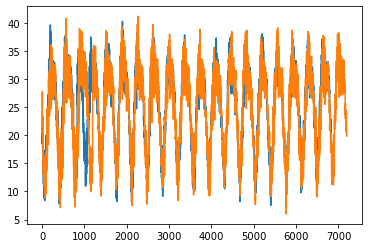

In [26]:
plt.plot(lr.predict(dft).reshape(6826,))

plt.plot(df1[' _tempm'].values)

In [27]:
dft = df1[' _tempm'][-365*3:]

for i in range(365):
        
        x = prepare_data(dft,365)
        
        x = pd.DataFrame(x)
        
        
        
        pred = lr.predict(x[-1:])[0][0]
        
        dft = np.append(dft,lr.predict(x[-1:])[0][0])

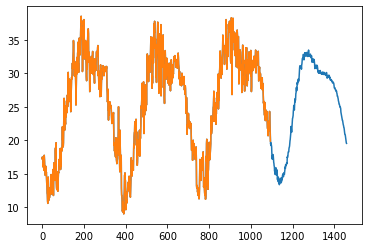

In [28]:
plt.plot(dft)

plt.plot(df1[' _tempm'][-365*3:].values)

# Enter a 'FUTURE DATE'

In [29]:
def find_temp():
    
    t1 = input('enter :')
    t2 = (pd.to_datetime(t1)-pd.to_datetime('2016-11-30')).days
    
    dft = df1[' _tempm'][-365*3:]

    for i in range(t2):
        
         x = prepare_data(dft,365)
        
         x = pd.DataFrame(x)
        
        
        
         pred = lr.predict(x[-1:])[0][0]
        
         dft = np.append(dft,lr.predict(x[-1:])[0][0])
            
    return(dft[-1])

In [30]:
find_temp()

enter :2017-11-05


23.82378027183919